Daily Challenge: Strategic Analysis of Superstore Performance


👩‍🏫 👩🏿‍🏫 What You’ll Learn
How to translate business objectives into actionable data analysis questions.
How to use Matplotlib and Seaborn for diagnostic and communicative visualizations.
How to create interactive widgets for dynamic data exploration.
How to derive and present actionable insights from retail sales data.
How to structure a professional analysis notebook and executive summary.


🛠️ What You Will Create
You’ll build a complete business intelligence report in a Jupyter Notebook using the US Superstore dataset. This will include interactive visualizations, deep-dive diagnostics, and strategic recommendations that simulate the role of a data analyst for a national retailer.



What Will You Use
Concepts: diagnostic analysis, exploratory vs. explanatory visualizations, profit margin, strategic KPIs
Libraries: Pandas, Matplotlib, Seaborn, ipywidgets
Techniques: time-series analysis, geographic analysis, discount strategy diagnostics, interactive dashboards


Your Task
Data Scoping and Preparation
Clean and preprocess your data:
🧹 Handle missing values and duplicates
Use appropriate methods (dropna(), fillna(), or imputation) and justify your choices for each case in markdown cells.




In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets # Это библиотека для: interactive widgets

from ipywidgets import interact, Dropdown, IntSlider

from IPython.display import display #Показывает объект красиво в notebook.

import warnings
warnings.filterwarnings('ignore')





In [22]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
type(df)

pandas.core.frame.DataFrame

In [4]:
# Basic data exploration
print("Dataset Shape:", df.shape) #shows table size

Dataset Shape: (9994, 21)


In [7]:
print("\nColumn Names:")
print(df.columns.tolist())



Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [36]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25


In [8]:
type(df.columns)

pandas.core.indexes.base.Index

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.describe() #Summary statistics for digital columns


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [23]:
df.isnull().sum() #Check missing values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [25]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()



Duplicate rows: 0


In [26]:
df = df.drop_duplicates()

In [27]:
# Handle missing values (example approach)
print("\nMissing values per column:")
print(df.isnull().sum())

# Example: Fill missing postal codes with 0 or remove rows
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0


In [17]:
print(df.shape)

(9994, 21)


In [28]:
#🕓 Fix data types
#Ensure that date columns are converted to datetime objects using pd.to_datetime() for time-series analysis.
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [30]:
date_columns = ['Order Date', 'Ship Date']
type(date_columns)

list

In [33]:
# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

In [ ]:
# Verify the conversion
print("Data types after conversion:")
print(df[date_columns].dtypes)

🏗️ Feature engineering
Create new features to enrich your analysis:

Profit Margin = (Profit / Sales) * 100

Order Year (e.g., df['Order Date'].dt.year)

Order Month (e.g., df['Order Date'].dt.month)


In [34]:
# Feature engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
type(df['Profit'])


pandas.core.series.Series

In [35]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [39]:
df['Order Year'] = df['Order Date'].dt.year
df[['Order Date', 'Order Year']].head()


,Order Date,Order Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [41]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M') #Преобразует дату → в monthly period.
df[['Order Date', 'Order Month-Year']].head()

,Order Date,Order Month-Year
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [38]:
# Display sample of new features
print("New features created:")
print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

New features created:
      Sales    Profit  Profit Margin  Order Year  Order Month
0  261.9600   41.9136          16.00        2016           11
1  731.9400  219.5820          30.00        2016           11
2   14.6200    6.8714          47.00        2016            6
3  957.5775 -383.0310         -40.00        2015           10
4   22.3680    2.5164          11.25        2015           10


2. Deep-Dive Exploratory Analysis (Matplotlib)

📈 Time-Series Trend Analysis
Create a line plot of total monthly Sales across all years using Matplotlib.
Add interactivity with ipywidgets.Dropdown to select a Product Category, dynamically updating the chart.

🔎 Look for patterns: seasonality, year-over-year changes, product-specific trends.

In [42]:
# Prepare data for time series analysis
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index() #reset_index() превращает результат обратно в нормальный DataFrame.
monthly_sales.head()


,Order Month-Year,Category,Sales
0,2014-01,Furniture,6242.525
1,2014-01,Office Supplies,4851.080
2,2014-01,Technology,3143.290
3,2014-02,Furniture,1839.658
4,2014-02,Office Supplies,1071.724


In [44]:
#Convert Period → Timestamp
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()
monthly_sales[['Order Month-Year', 'Date']].head()

,Order Month-Year,Date
0,2014-01,2014-01-01
1,2014-01,2014-01-01
2,2014-01,2014-01-01
3,2014-02,2014-02-01
4,2014-02,2014-02-01


In [46]:
# Interactive time series plot
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # Plot total sales across all categories
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        # Plot sales for specific category
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'],
                marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

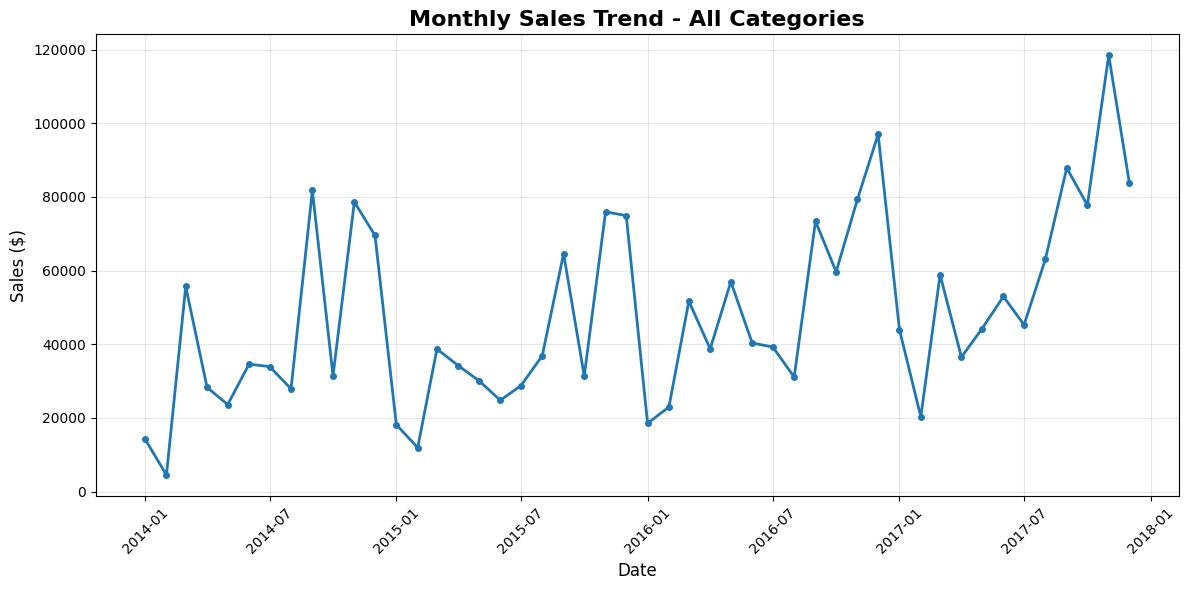

In [47]:
plot_monthly_sales()

In [48]:
categories = ['All'] + list(df['Category'].unique())

category_dropdown = Dropdown(
    options=categories,
    value='All',
    description='Category:'
)
interact(
    plot_monthly_sales,
    category=category_dropdown
)

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

<function __main__.plot_monthly_sales(category='All')>

🗺️ Geographic Sales Performance
Build a horizontal bar chart showing total sales by State, sorted by amount.
Add a Top N slider widget to dynamically filter the number of displayed states.

💬 Identify high-performing states. Are sales centralized or geographically distributed?



In [50]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
state_sales.head()

,Sales
State,
North Dakota,919.910
West Virginia,1209.824
Maine,1270.530
South Dakota,1315.560
Wyoming,1603.136


In [51]:
state_sales.index

Index(['North Dakota', 'West Virginia', 'Maine', 'South Dakota', 'Wyoming',
       'District of Columbia', 'Kansas', 'Idaho', 'Iowa', 'New Mexico',
       'Montana', 'New Hampshire', 'Nebraska', 'South Carolina', 'Vermont',
       'Louisiana', 'Mississippi', 'Utah', 'Arkansas', 'Connecticut', 'Nevada',
       'Oregon', 'Alabama', 'Oklahoma', 'Missouri', 'Rhode Island', 'Maryland',
       'Delaware', 'Massachusetts', 'Minnesota', 'Tennessee', 'Colorado',
       'Wisconsin', 'Arizona', 'New Jersey', 'Kentucky', 'Georgia', 'Indiana',
       'North Carolina', 'Virginia', 'Michigan', 'Ohio', 'Illinois', 'Florida',
       'Pennsylvania', 'Washington', 'Texas', 'New York', 'California'],
      dtype='object', name='State')

In [52]:
state_sales.values

array([   919.91  ,   1209.824 ,   1270.53  ,   1315.56  ,   1603.136 ,
         2865.02  ,   2914.31  ,   4382.486 ,   4579.76  ,   4783.522 ,
         5589.352 ,   7292.524 ,   7464.93  ,   8481.71  ,   8929.37  ,
         9217.03  ,  10771.34  ,  11220.056 ,  11678.13  ,  13384.357 ,
        16729.102 ,  17431.15  ,  19510.64  ,  19683.39  ,  22205.15  ,
        22627.956 ,  23705.523 ,  27451.069 ,  28634.434 ,  29863.15  ,
        30661.873 ,  32108.118 ,  32114.61  ,  35282.001 ,  35764.312 ,
        36591.75  ,  49095.84  ,  53555.36  ,  55603.164 ,  70636.72  ,
        76269.614 ,  78258.136 ,  80166.101 ,  89473.708 , 116511.914 ,
       138641.27  , 170188.0458, 310876.271 , 457687.6315])

In [61]:
# Interactive geographic analysis
#default value - 10
def plot_top_states(top_n=10):
  plt.figure(figsize=(12, max(6, top_n * 0.4))) ##Чтобы figure автоматически становилась выше, если штатов много.

  # Get top N states
  top_states = state_sales.tail(top_n)

  # Create horizontal bar chart
  bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
  plt.yticks(range(len(top_states)), top_states.index)
  plt.xlabel('Total Sales ($)', fontsize=12)
  plt.ylabel('State', fontsize=12)
  plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

  # Add value labels on bars
  for i, (state, value) in enumerate(top_states.items()):
      plt.text(value + max(top_states.values) * 0.01, i, f'${value:,.0f}',
              va='center', fontsize=10)

  plt.grid(axis='x', alpha=0.3)
  plt.tight_layout()
  plt.show()

  print(f"Total states analyzed: {len(state_sales)}")
  print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales")

# Create interactive slider
top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);


interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

3. Communicating Insights (Seaborn)

🏆 Top 10 Most Profitable Products
Use Seaborn’s barplot() to show the top 10 products by total profit.
- Orient horizontally, label axes clearly, and annotate bars with exact profit values.
- Give the chart a descriptive title suitable for an executive summary.

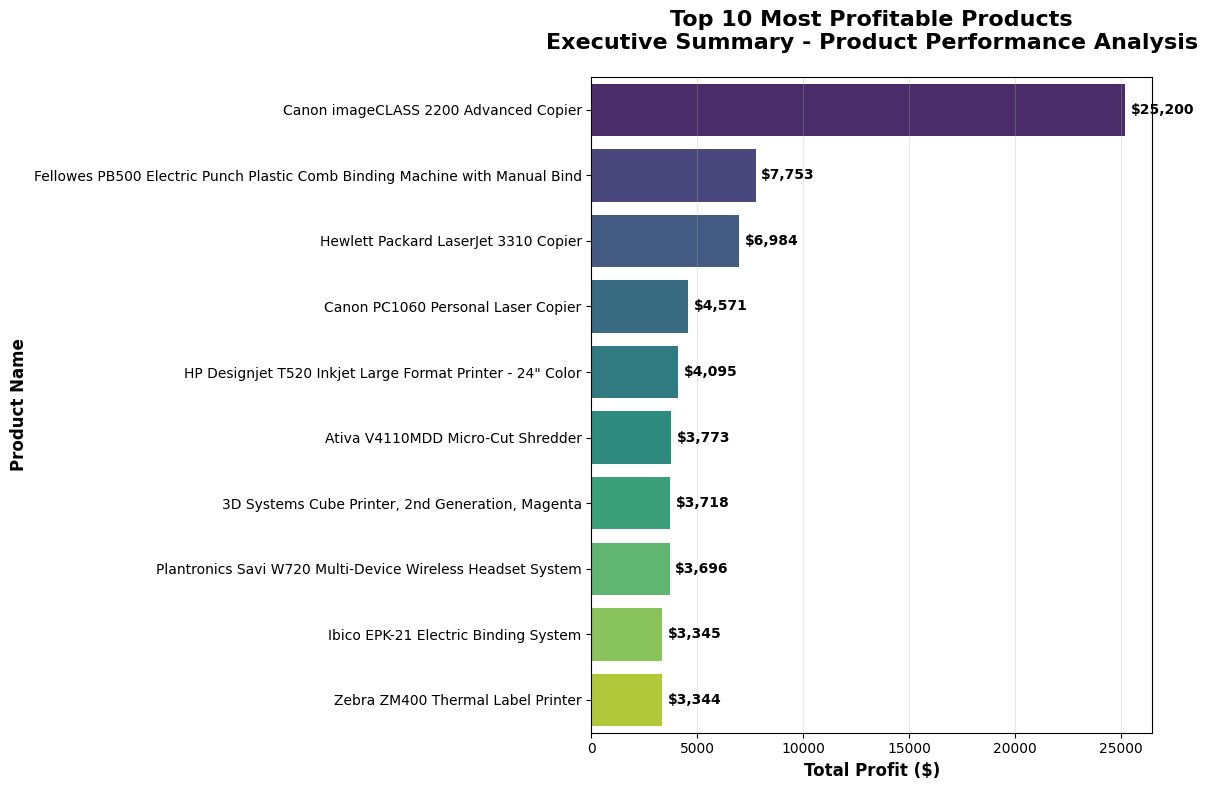

Key Insights:
• Most profitable product generates: $25,200
• Top 10 products contribute: $66,479 total profit
• Average profit per top product: $6,648


In [63]:
# Analyze top profitable products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                palette='viridis', orient='h')

# Customize the plot
plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

# Add value annotations
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max(product_profit.values) * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insights:")
print(f"• Most profitable product generates: ${product_profit.iloc[0]:,.0f}")
print(f"• Top 10 products contribute: ${product_profit.sum():,.0f} total profit")
print(f"• Average profit per top product: ${product_profit.mean():,.0f}")

🔍 Discount vs Profit Scatter Plot
Use sns.scatterplot() to visualize the relationship between Discount and Profit.
- Add hue=Product Category to reveal category-level trends.
- Overlay a regplot() to visualize trend lines.

❗ What discount level starts correlating with consistent losses? Varying trends by category?



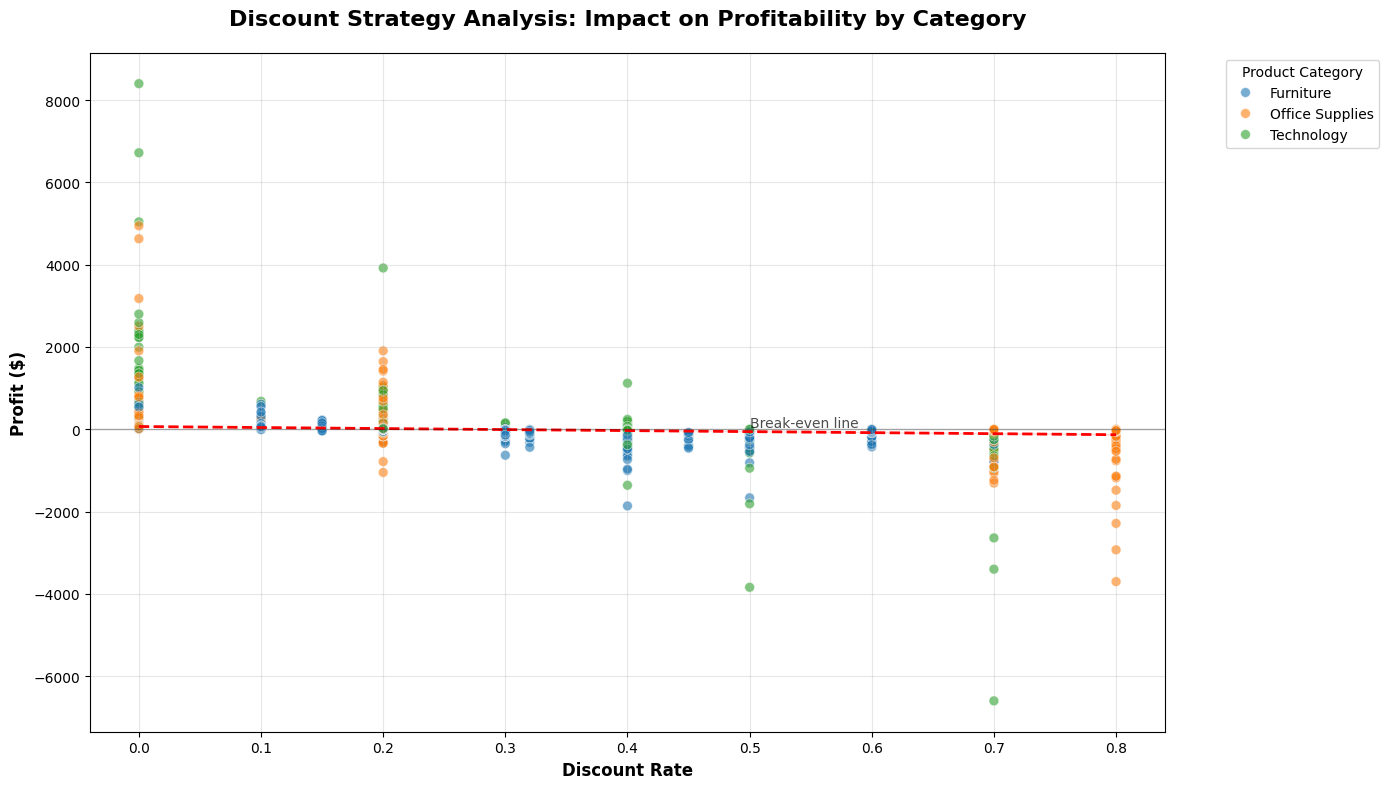

Discount Analysis Insights:
• Transactions with >20% discount: 1,393
• Average profit for high discounts: $-97.18
• Percentage of high-discount sales with losses: 96.8%

Category-specific discount impact:
• Furniture: Average profit at >20% discount = $-100.51
• Office Supplies: Average profit at >20% discount = $-69.32
• Technology: Average profit at >20% discount = $-197.42


In [64]:
# Discount vs Profit Analysis
plt.figure(figsize=(14, 8))

# Create the scatter plot with category colors
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
               alpha=0.6, s=50) # alpha=0.6 - прозрачность точек

# Add regression line for overall trend
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
           color='red', line_kws={'linewidth': 2, 'linestyle': '--'}) #scatter=false - Не рисовать точки повторно, line_kws - Словарь настроек линии.

# Customize the plot
plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')

# Add horizontal line at profit = 0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left') #bbox_to_anchor - legend
plt.tight_layout()
plt.show()

# Analytical insights
print("Discount Analysis Insights:")
high_discount = df[df['Discount'] > 0.2]  # Discounts above 20%
print(f"• Transactions with >20% discount: {len(high_discount):,}")
print(f"• Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"• Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%")

# Category-specific analysis
print("\nCategory-specific discount impact:")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_loss = high_disc_cat['Profit'].mean()
        print(f"• {category}: Average profit at >20% discount = ${avg_loss:.2f}")

4. Methodology and Tooling Review

Create a markdown cell with a comparative evaluation of Matplotlib vs. Seaborn:



In [66]:
# Code to demonstrate library comparison
print("=== LIBRARY COMPARISON ANALYSIS ===")
print()

# Matplotlib strengths demonstrated
print("MATPLOTLIB STRENGTHS (from our analysis):")
print("• Fine-grained control over interactive widgets")
print("• Custom annotations and text positioning")
print("• Precise subplot layouts and figure sizing")
print("• Integration with ipywidgets for dynamic updates")
print()

# Seaborn strengths demonstrated
print("SEABORN STRENGTHS (from our analysis):")
print("• Built-in statistical visualizations (regplot)")
print("• Automatic color palettes and legends")
print("• Clean, publication-ready default styling")
print("• Easy categorical data visualization")
print()

print("SPEED COMPARISON:")
import time #NEW Библиотека для времени.

# Time a simple matplotlib plot
start = time.time() #Возвращает текущее время.
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

# Time a seaborn plot
start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Matplotlib basic plot: {matplotlib_time:.4f} seconds")
print(f"• Seaborn equivalent: {seaborn_time:.4f} seconds")

=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS (from our analysis):
• Fine-grained control over interactive widgets
• Custom annotations and text positioning
• Precise subplot layouts and figure sizing
• Integration with ipywidgets for dynamic updates

SEABORN STRENGTHS (from our analysis):
• Built-in statistical visualizations (regplot)
• Automatic color palettes and legends
• Clean, publication-ready default styling
• Easy categorical data visualization

SPEED COMPARISON:
• Matplotlib basic plot: 0.0191 seconds
• Seaborn equivalent: 0.0685 seconds
